In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [2]:
model_path = "../models/best_yolo8m_ball-detection.pt"
model = YOLO(model_path)

In [3]:
video_path = "../input_video/08fd33_4.mp4"

cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
num_samples = 10  # ganti jadi 5 kalau mau lebih sedikit

# Ambil frame secara merata
frame_indices = np.linspace(0, total_frames - 1, num_samples, dtype=int)

frames = []

for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

cap.release()

print(f"Berhasil ambil {len(frames)} frame")

Berhasil ambil 10 frame


In [4]:
results = model(frames, imgsz=1280, conf=0.25)


0: 736x1280 1 ball, 3795.7ms
1: 736x1280 1 ball, 3795.7ms
2: 736x1280 2 balls, 3795.7ms
3: 736x1280 3 balls, 3795.7ms
4: 736x1280 1 ball, 3795.7ms
5: 736x1280 2 balls, 3795.7ms
6: 736x1280 2 balls, 3795.7ms
7: 736x1280 6 balls, 3795.7ms
8: 736x1280 5 balls, 3795.7ms
9: 736x1280 4 balls, 3795.7ms
Speed: 18.2ms preprocess, 3795.7ms inference, 5.3ms postprocess per image at shape (1, 3, 736, 1280)


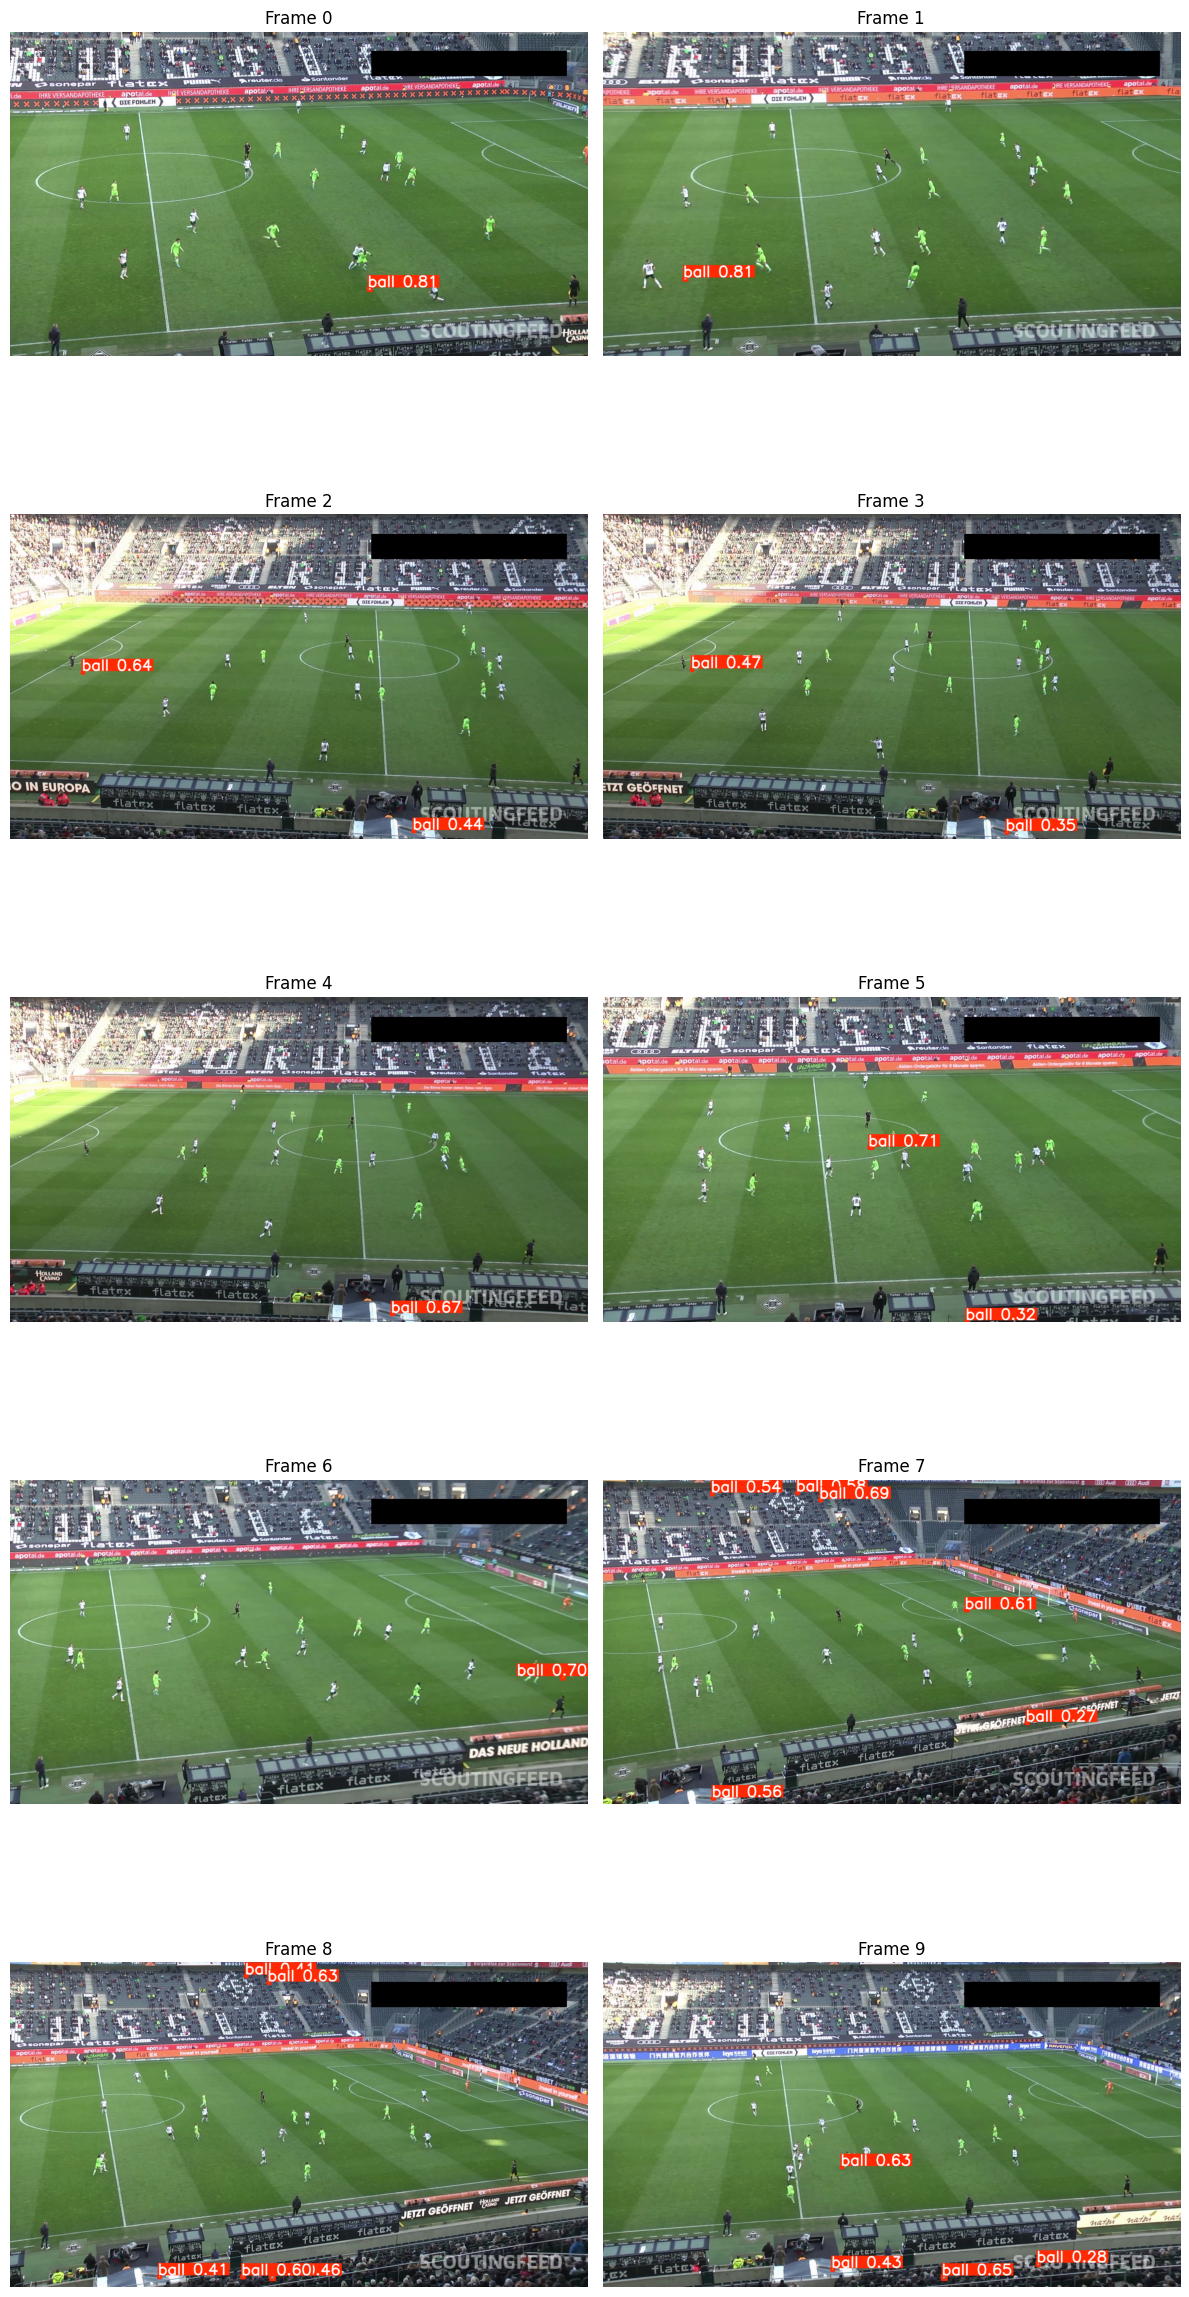

In [5]:
num_frames = len(results)

cols = 2 
rows = (num_frames + cols - 1) // cols

plt.figure(figsize=(12, rows * 5))  # tinggi otomatis ikut jumlah row

for i, result in enumerate(results):
    annotated = result.plot()
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(annotated)
    plt.title(f"Frame {i}", fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
for i, result in enumerate(results):
    print(f"Frame {i}")
    for box in result.boxes:
        print("  Conf:", float(box.conf))
        print("  Class:", int(box.cls))
        print("  BBox:", box.xyxy.tolist())
    print("------")

Frame 0
  Conf: 0.8136937618255615
  Class: 0
  BBox: [[1188.087890625, 851.7068481445312, 1201.8358154296875, 864.7750854492188]]
------
Frame 1
  Conf: 0.8140573501586914
  Class: 0
  BBox: [[266.52301025390625, 818.4345703125, 280.2988586425781, 829.3868408203125]]
------
Frame 2
  Conf: 0.6370336413383484
  Class: 0
  BBox: [[238.74229431152344, 521.9952392578125, 246.1128387451172, 530.3527221679688]]
  Conf: 0.4431484639644623
  Class: 0
  BBox: [[1337.535888671875, 1049.970458984375, 1346.3258056640625, 1057.68359375]]
------
Frame 3
  Conf: 0.46666014194488525
  Class: 0
  BBox: [[292.8211364746094, 512.6881713867188, 299.6124572753906, 522.0018310546875]]
  Conf: 0.36518529057502747
  Class: 0
  BBox: [[292.5603942871094, 509.9973449707031, 299.32635498046875, 519.3455810546875]]
  Conf: 0.34685659408569336
  Class: 0
  BBox: [[1337.7449951171875, 1052.4228515625, 1346.793701171875, 1062.00439453125]]
------
Frame 4
  Conf: 0.6708498597145081
  Class: 0
  BBox: [[1265.89489746